<a href="https://colab.research.google.com/github/iam-mukeshvenkatesh/Machine-Learning-Concepts/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Principal Component Analysis (PCA)

This notebook demonstrates Principal Component Analysis on the Breast Cancer dataset.
PCA is a dimensionality reduction technique that identifies the directions of maximum variance in the data.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Explore the Data

In [2]:
# Load the dataset
df = pd.read_csv("breast-cancer.csv")
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (569, 32)

First few rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum().sum())

# Display basic statistics
print("\nDataset Info:")
print(f"Total samples: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")
print(f"\nDiagnosis distribution:")
print(df['diagnosis'].value_counts())

Missing values per column:
0

Dataset Info:
Total samples: 569
Total features: 32

Diagnosis distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


## 2. Data Preprocessing

In [4]:
# Encode categorical variable (diagnosis)
df_encoded = pd.get_dummies(df, dtype=int)
print("Encoded dataset shape:", df_encoded.shape)
print("\nFirst few rows after encoding:")
df_encoded.head()

Encoded dataset shape: (569, 33)

First few rows after encoding:


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_B,diagnosis_M
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,1
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,1
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,1
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,1
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,1


In [5]:
# Check for missing values after encoding
missing_values = df_encoded.isnull().sum()
if missing_values.sum() == 0:
    print("✓ No missing values found")
else:
    print("Missing values:")
    print(missing_values[missing_values > 0])

✓ No missing values found


In [6]:
# Remove outliers using IQR method
def remove_outliers(data):
    """
    Remove outliers using Interquartile Range (IQR) method
    """
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - (1.5 * IQR)
    upper_limit = Q3 + (1.5 * IQR)
    return data[(data >= lower_limit) & (data <= upper_limit)]

# Apply outlier removal
print(f"Original dataset shape: {df_encoded.shape}")
for col in df_encoded.columns:
    df_encoded = df_encoded[(df_encoded[col] >= df_encoded[col].quantile(0.25) - 1.5 * (df_encoded[col].quantile(0.75) - df_encoded[col].quantile(0.25))) &
                             (df_encoded[col] <= df_encoded[col].quantile(0.75) + 1.5 * (df_encoded[col].quantile(0.75) - df_encoded[col].quantile(0.25)))]

print(f"Dataset shape after outlier removal: {df_encoded.shape}")
print(f"Rows removed: {569 - df_encoded.shape[0]}")

Original dataset shape: (569, 33)
Dataset shape after outlier removal: (219, 33)
Rows removed: 350


## 3. Feature Standardization

In [7]:
# Extract features and standardize
X = df_encoded.values
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print("Standardized data statistics:")
print(f"Mean: {X_std.mean():.6f}")
print(f"Std Dev: {X_std.std():.6f}")
print(f"Data shape: {X_std.shape}")

Standardized data statistics:
Mean: 0.000000
Std Dev: 0.969223
Data shape: (219, 33)


## 4. Apply PCA

In [8]:
# Apply PCA to all components
pca = PCA()
principal_components = pca.fit_transform(X_std)

# Create DataFrame with principal components
principal_df = pd.DataFrame(
    data=principal_components,
    columns=[f'PC{i+1}' for i in range(principal_components.shape[1])]
)

print(f"Principal components shape: {principal_df.shape}")
print("\nFirst few rows of principal components:")
principal_df.head()

Principal components shape: (219, 33)

First few rows of principal components:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33
0,3.494670,0.247372,-0.500541,-1.373685,-0.225448,1.775617,-1.828522,1.746907,-0.873801,0.903141,...,-0.122474,-0.049164,-0.172114,-0.050863,-0.123767,-0.012795,-0.025223,0.000576,5.076805e-17,2.242294e-16
1,2.102380,1.200922,-2.628894,-0.287851,0.822821,1.916470,1.770411,1.043577,0.291473,-1.708587,...,-0.146004,-0.183736,0.078854,0.083244,-0.061968,0.014619,0.007402,-0.019684,7.169830e-17,3.385758e-16
2,-3.037255,3.962910,-0.030395,-1.982718,-0.549459,-0.148091,-1.632139,2.570050,-0.637543,-1.259856,...,0.035186,-0.128684,-0.015776,0.025885,0.158881,-0.002645,-0.008949,0.002672,3.976175e-16,-7.823331e-17
3,-2.523731,-2.292544,1.492370,0.638531,-1.207205,0.154959,-2.800806,-0.456106,2.662438,-1.593936,...,-0.554826,0.027893,0.221537,0.030671,-0.115593,0.014122,-0.004910,-0.001034,1.228329e-17,3.392211e-16
4,1.197440,1.166523,-1.849114,-0.330487,-0.595822,-0.392716,0.394620,-0.527467,-1.877618,0.084595,...,0.041502,-0.006101,-0.120765,-0.304359,-0.002141,0.013191,-0.001416,-0.005100,-2.708889e-16,6.793331e-16


## 5. Analyze Explained Variance

In [9]:
# Calculate explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Display variance information
print("Explained Variance by Component:")
print("="*50)
for i, (ind, cum) in enumerate(zip(explained_variance[:10], cumulative_variance[:10])):
    print(f"PC{i+1}: {ind:.4f} (Cumulative: {cum:.4f})")

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nComponents needed for 95% variance: {n_components_95}")
print(f"Total variance explained: {cumulative_variance[-1]:.4f}")

Explained Variance by Component:
PC1: 0.2971 (Cumulative: 0.2971)
PC2: 0.2354 (Cumulative: 0.5325)
PC3: 0.1161 (Cumulative: 0.6486)
PC4: 0.0731 (Cumulative: 0.7217)
PC5: 0.0533 (Cumulative: 0.7750)
PC6: 0.0515 (Cumulative: 0.8265)
PC7: 0.0327 (Cumulative: 0.8592)
PC8: 0.0298 (Cumulative: 0.8890)
PC9: 0.0246 (Cumulative: 0.9136)
PC10: 0.0187 (Cumulative: 0.9323)

Components needed for 95% variance: 12
Total variance explained: 1.0000


## 6. Visualize Scree Plot

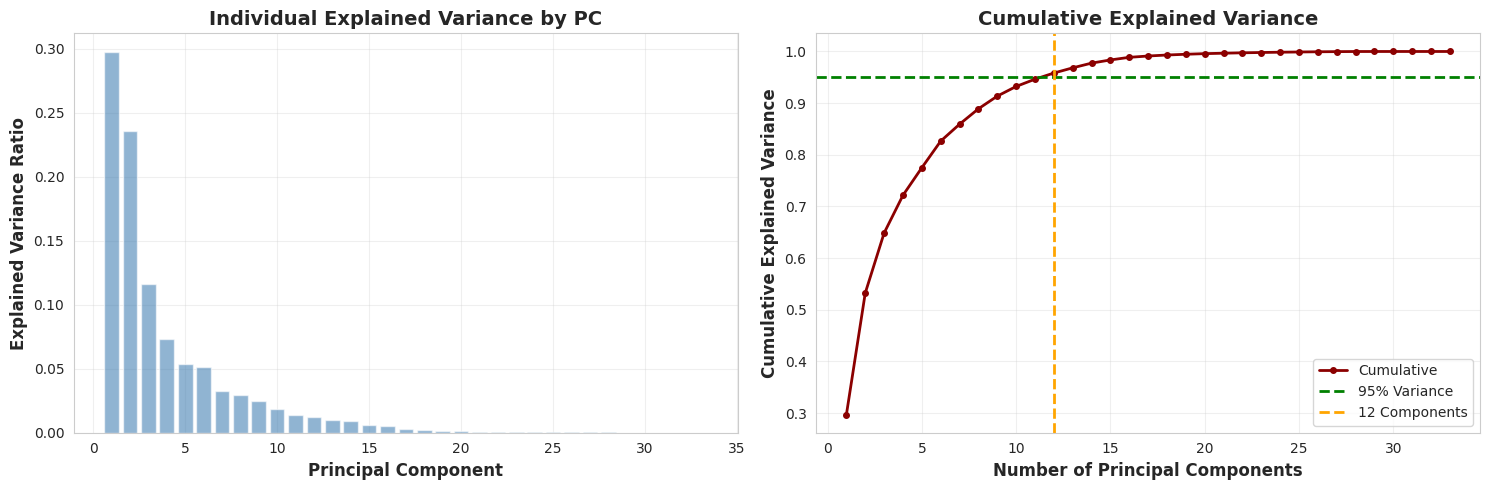

In [10]:
# Create scree plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot individual explained variance
ax1.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.6, color='steelblue', label='Individual')
ax1.set_xlabel('Principal Component', fontsize=12, fontweight='bold')
ax1.set_ylabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
ax1.set_title('Individual Explained Variance by PC', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot cumulative explained variance
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-', color='darkred', linewidth=2, markersize=4, label='Cumulative')
ax2.axhline(y=0.95, color='green', linestyle='--', linewidth=2, label='95% Variance')
ax2.axvline(x=n_components_95, color='orange', linestyle='--', linewidth=2, label=f'{n_components_95} Components')
ax2.set_xlabel('Number of Principal Components', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Explained Variance', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Visualize PC1 vs PC2

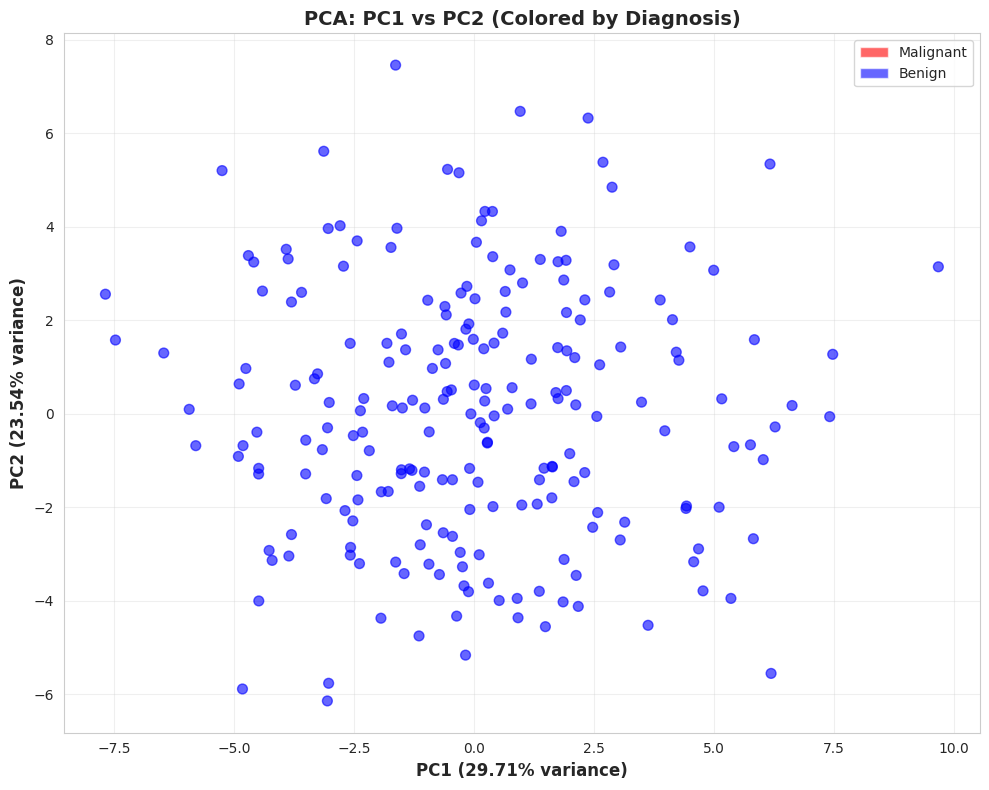

In [11]:
# Create scatter plot for PC1 vs PC2
plt.figure(figsize=(10, 8))

# Add diagnosis information for coloring
diagnosis_values = df_encoded['diagnosis_M'].values
colors = ['red' if x == 1 else 'blue' for x in diagnosis_values]

scatter = plt.scatter(principal_df['PC1'], principal_df['PC2'], c=colors, alpha=0.6, s=50)

plt.xlabel(f'PC1 ({explained_variance[0]:.2%} variance)', fontsize=12, fontweight='bold')
plt.ylabel(f'PC2 ({explained_variance[1]:.2%} variance)', fontsize=12, fontweight='bold')
plt.title('PCA: PC1 vs PC2 (Colored by Diagnosis)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Create legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', alpha=0.6, label='Malignant'),
                   Patch(facecolor='blue', alpha=0.6, label='Benign')]
plt.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

## 8. Feature Contribution Analysis

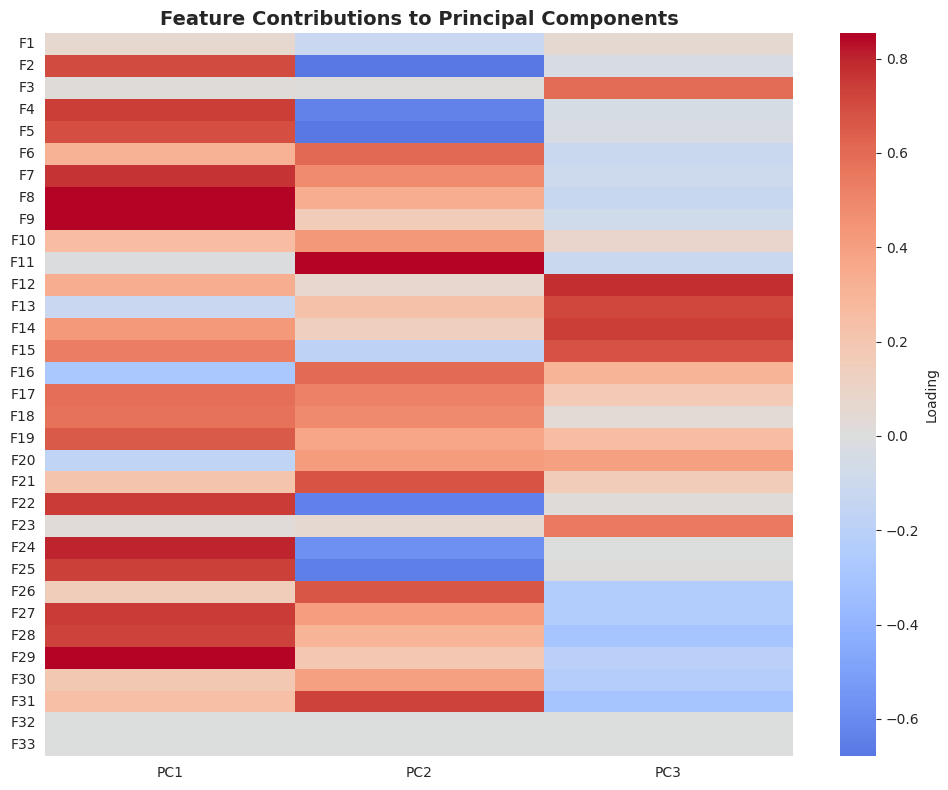

Feature loadings shape: (33, 3)


In [12]:
# Get feature contributions for first 3 PCs
loadings = pca.components_[:3].T * np.sqrt(pca.explained_variance_[:3])

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 8))
feature_names = [f'F{i+1}' for i in range(loadings.shape[0])]
component_names = ['PC1', 'PC2', 'PC3']

sns.heatmap(loadings,
            xticklabels=component_names,
            yticklabels=feature_names,
            cmap='coolwarm',
            center=0,
            cbar_kws={'label': 'Loading'},
            ax=ax)

ax.set_title('Feature Contributions to Principal Components', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Feature loadings shape:", loadings.shape)

## 9. 3D Visualization

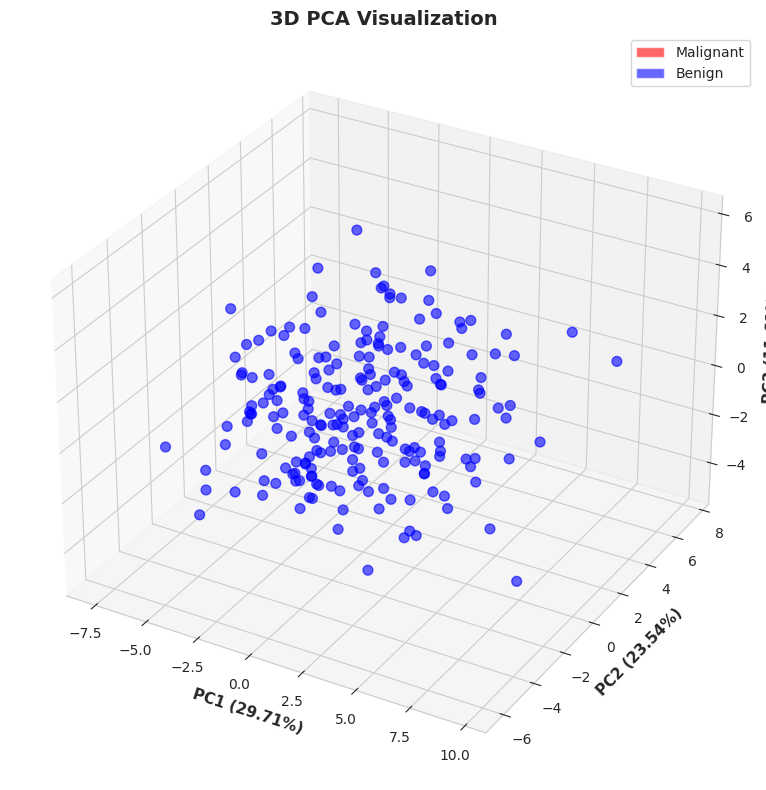

In [13]:
from mpl_toolkits.mplot3d import Axes3D

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot points
scatter = ax.scatter(principal_df['PC1'], principal_df['PC2'], principal_df['PC3'],
                      c=colors, alpha=0.6, s=50)

ax.set_xlabel(f'PC1 ({explained_variance[0]:.2%})', fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({explained_variance[1]:.2%})', fontsize=11, fontweight='bold')
ax.set_zlabel(f'PC3 ({explained_variance[2]:.2%})', fontsize=11, fontweight='bold')
ax.set_title('3D PCA Visualization', fontsize=14, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', alpha=0.6, label='Malignant'),
                   Patch(facecolor='blue', alpha=0.6, label='Benign')]
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

## 10. Summary Statistics

In [14]:
# Summary of PCA analysis
print("\n" + "="*60)
print("PCA ANALYSIS SUMMARY")
print("="*60)
print(f"Original features: {X_std.shape[1]}")
print(f"Original samples: {X_std.shape[0]}")
print(f"\nComponents for 90% variance: {np.argmax(cumulative_variance >= 0.90) + 1}")
print(f"Components for 95% variance: {np.argmax(cumulative_variance >= 0.95) + 1}")
print(f"Components for 99% variance: {np.argmax(cumulative_variance >= 0.99) + 1}")
print(f"\nDimensionality reduction: {X_std.shape[1]} -> {n_components_95} features")
print(f"Reduction ratio: {((X_std.shape[1] - n_components_95) / X_std.shape[1] * 100):.2f}%")
print("="*60)


PCA ANALYSIS SUMMARY
Original features: 33
Original samples: 219

Components for 90% variance: 9
Components for 95% variance: 12
Components for 99% variance: 17

Dimensionality reduction: 33 -> 12 features
Reduction ratio: 63.64%
